Division du sample en 75/25

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Charger votre base de données avec le séparateur ;
data = pd.read_csv("SOFIFAZ.csv", sep=';', encoding = "utf8")

# Division des données en 75 % apprentissage et 25 % test
train_set, test_set = train_test_split(data, test_size=0.25, random_state=42)

# Sauvegarder les ensembles avec le même séparateur ;
train_set.to_csv("train_set.csv", sep=';', index=False)
test_set.to_csv("test_set.csv", sep=';', index=False)

print(f"Taille de l'ensemble d'apprentissage : {train_set.shape}")
print(f"Taille de l'ensemble de validation : {test_set.shape}")


Taille de l'ensemble d'apprentissage : (429, 30)
Taille de l'ensemble de validation : (143, 30)


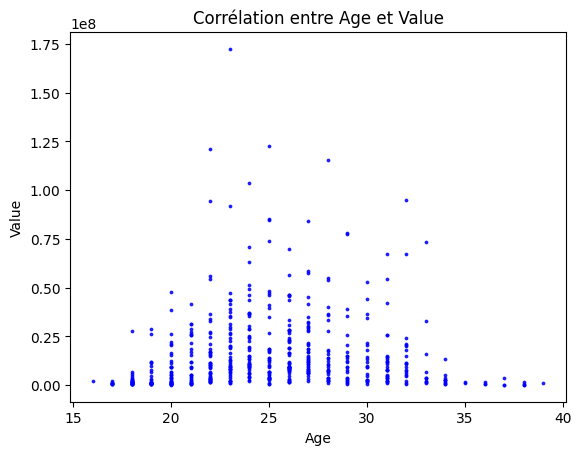

C:\Users\ducar\AppData\Local\Temp\ipykernel_22600\72338317.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


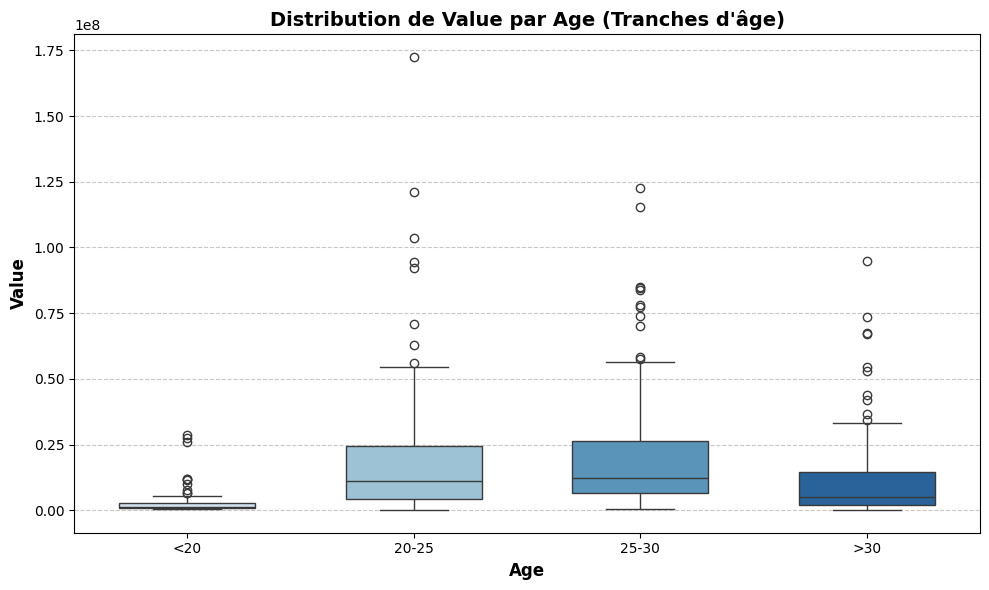

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
data = pd.read_csv("SOFIFAZ.csv", sep=';', encoding = "utf8")



#afficher le graphique nuage de points entre deux colonnes
def plot_correlation(data, x, y):
    plt.scatter(data[x], data[y], color="Blue",s=3, alpha=0.8) #s=taille des points, alpha=transparence
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title('Corrélation entre ' + x + ' et ' + y)
    plt.show()
plot_correlation(data, 'Age', 'Value')

#Histogramme d'une colonne
def plot_hist(data, x):
    plt.hist(data[x], bins=10, edgecolor='black') #bins = nombre de barres, edgecolor pour les lignes noires
    plt.xlabel(x)
    plt.ylabel('Nombre de joueurs')
    plt.title('Histogramme de ' + x)
    plt.show()

# Fonction pour créer un boxplot avec une échelle Y ajustée
def plot_boxplot_with_age_bins(data, x, y):
    # Créer des tranches d'âge
    bins = [0, 20, 25, 30, float('inf')]  # Définir les intervalles de tranches
    labels = ['<20', '20-25', '25-30', '>30']  # Noms des tranches
    data['Age_bins'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

    # Créer le boxplot
    plt.figure(figsize=(10, 6))  # Taille du graphique
    sns.boxplot(
        data=data,
        x='Age_bins',  # Tranches d'âge comme axe X
        y=x,  # Variable Y (Value)
        palette="Blues",  # Palette de couleurs
        showfliers=True,  # Afficher les outliers
        width=0.6  # Largeur des boxplots
    )
    plt.title(f'Distribution de {x} par {y} (Tranches d\'âge)', fontsize=14, weight='bold')
    plt.xlabel(y, fontsize=12, weight='bold')
    plt.ylabel(x, fontsize=12, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Ajouter une grille discrète
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
# Remplacez 'data' par votre DataFrame et 'Value' comme valeur à analyser
plot_boxplot_with_age_bins(data, 'Value', 'Age')
#Graphique en camembert
def plot_pie(data, x,title):
    plt.figure(figsize=(4, 4))  # Taille de la figure
    plt.title(title, fontsize=12)  # Titre
    data[x].value_counts().plot.pie(
        autopct='%1.1f%%',  # Format des pourcentages
        startangle=90,  # Angle de départ
        colors=plt.cm.Blues(np.linspace(0.3, 0.9, data[x].nunique())),  # Palette de tons bleus
        textprops={'fontsize': 10}  # Taille des textes
    )
    plt.ylabel('')  # Supprimer l'étiquette de l'axe Y
    plt.show()


#afficher la régréssion linéaire entre colonnes Value et Age
def plot_regression(data, x, y):
    # Calculer les coefficients de la régression linéaire
    slope, intercept = np.polyfit(data[x], data[y], 1)
    # Afficher les points de données
    plt.scatter(data[x], data[y], label='Données')
    # Afficher la ligne de régression
    plt.plot(data[x], slope * data[x] + intercept, color='red', label='Régression linéaire')   
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title('Régression linéaire entre ' + x + ' et ' + y)
    plt.legend()
    plt.show()
    # Afficher les coefficients
    print(f'Coefficient de régression (pente): {slope}')
    print(f'Ordonnée à l\'origine: {intercept}')

#fichier csv avec les infos de chaque colonne (min, max, moyenne, médiane, écart-type,quartiles)
def save_column_stats_to_excel(data, filename):
    # Sélectionner uniquement les colonnes numériques
    numeric_data = data.select_dtypes(include=['number'])
    
    # Vérifier qu'il y a des colonnes numériques
    if numeric_data.empty:
        print("Aucune colonne numérique dans les données.")
        return
    # deselctionner la colonne ID, Joine
    numeric_data = numeric_data.drop(columns=['ID', 'Joined'])
    
    # Calcul des statistiques descriptives
    stats = numeric_data.describe().T  # Transposer pour avoir une ligne par variable
    stats['median'] = numeric_data.median()  # Ajouter la médiane
    stats['quartile_1'] = numeric_data.quantile(0.25)  # Ajouter le 1er quartile
    stats['quartile_3'] = numeric_data.quantile(0.75)  # Ajouter le 3e quartile

    # Renommer les colonnes pour des noms en français
    stats = stats.rename(columns={
        'mean': 'moyenne',
        'std': 'écart-type',
        'min': 'min',
        'max': 'max'
    })
    
    # Réorganiser les colonnes pour un ordre logique
    stats = stats[['min', 'max', 'moyenne', 'median', 'écart-type', 'quartile_1', 'quartile_3']]
    
    # Sauvegarder les statistiques dans un fichier Excel
    stats.to_excel(filename, index=True)
    print(f"Les statistiques descriptives ont été sauvegardées dans : {filename}")

In [36]:
def spearman_correlation_table(data, filename=None):
    # Sélectionner uniquement les colonnes numériques
    numeric_data = data.select_dtypes(include=['number'])
    #retirer la colonne ID
    numeric_data = numeric_data.drop(columns=['ID'])
    # Calculer la matrice de corrélation de Spearman
    spearman_corr_matrix = numeric_data.corr(method='spearman')
    
    # Afficher la matrice sous forme de tableau
    print("Matrice des corrélations de Spearman :")
    print(spearman_corr_matrix)
    
    # Enregistrer la matrice dans un fichier Excel ou CSV (optionnel)
    if filename:
        spearman_corr_matrix.to_csv(filename, index=True)
        print(f"Matrice des corrélations de Spearman sauvegardée dans : {filename}")
    
    return spearman_corr_matrix
spearman_corr_matrix = spearman_correlation_table(data, filename="spearmancorr.csv")



Matrice des corrélations de Spearman :
                  Overall rating  Potential    Growth       Age    Height  \
Overall rating          1.000000   0.601417 -0.512544  0.423270  0.001569   
Potential               0.601417   1.000000  0.276989 -0.341022 -0.067465   
Growth                 -0.512544   0.276989  1.000000 -0.953050 -0.060104   
Age                     0.423270  -0.341022 -0.953050  1.000000  0.129722   
Height                  0.001569  -0.067465 -0.060104  0.129722  1.000000   
Weight                  0.119182  -0.058404 -0.185967  0.250151  0.756852   
Value                   0.943432   0.758151 -0.264571  0.152119 -0.054440   
Wage                    0.895827   0.501286 -0.523792  0.427375 -0.057679   
Attacking               0.535916   0.327602 -0.314897  0.198133 -0.363209   
Skill                   0.548977   0.385841 -0.273870  0.155554 -0.480186   
Movement                0.362196   0.434147  0.033987 -0.168325 -0.661169   
Power                   0.596550   0.

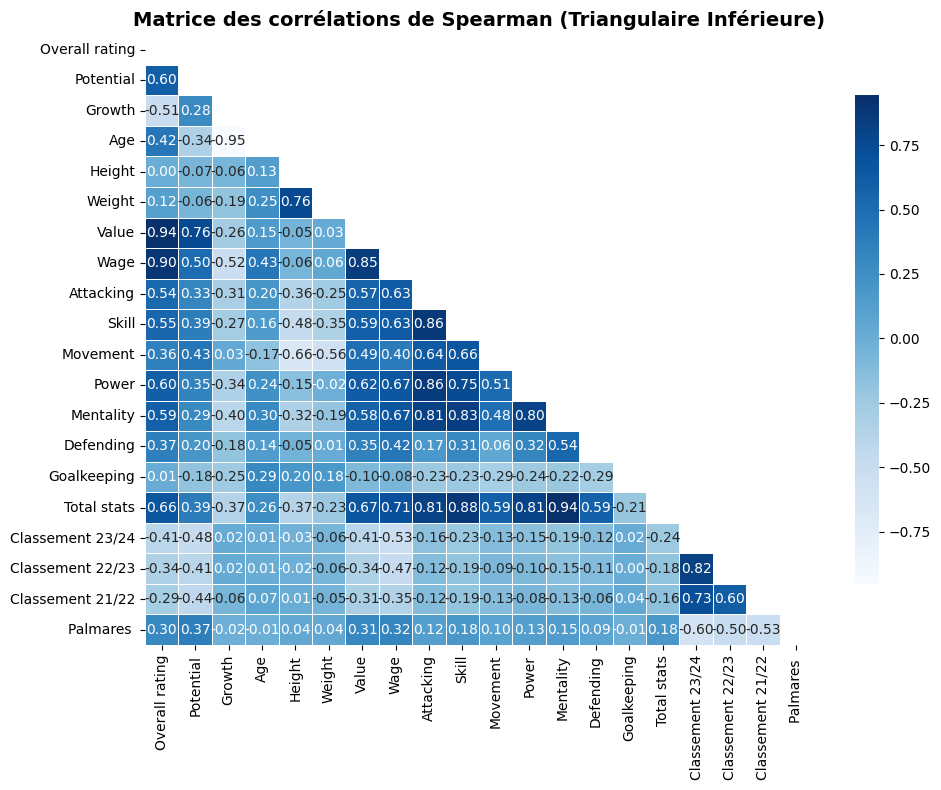

In [37]:
def plot_spearman_correlation_heatmap(corr_matrix):
    plt.figure(figsize=(10, 8))

    # Créer un masque pour cacher la moitié supérieure
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Heatmap avec le masque appliqué
    sns.heatmap(
        corr_matrix,
        mask=mask,  # Masquer la moitié supérieure
        annot=True,  # Afficher les valeurs
        cmap='Blues',  # Palette de couleurs
        fmt=".2f",  # Format des valeurs numériques
        linewidths=0.5,  # Espacement entre les cases
        cbar_kws={"shrink": 0.8}  # Ajuster la barre des couleurs
    )

    plt.title("Matrice des corrélations de Spearman (Triangulaire Inférieure)", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
plot_spearman_correlation_heatmap(spearman_corr_matrix)

In [38]:
threshold = 0.7
for i in range(len(spearman_corr_matrix.columns)):
    for j in range(i+1, len(spearman_corr_matrix.columns)):
        corr_value = spearman_corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            print(f"({spearman_corr_matrix.columns[i]}, {spearman_corr_matrix.columns[j]}, {corr_value:.2f})")

(Overall rating, Value, 0.94)
(Overall rating, Wage, 0.90)
(Potential, Value, 0.76)
(Growth, Age, -0.95)
(Height, Weight, 0.76)
(Value, Wage, 0.85)
(Wage, Total stats, 0.71)
(Attacking, Skill, 0.86)
(Attacking, Power, 0.86)
(Attacking, Mentality, 0.81)
(Attacking, Total stats, 0.81)
(Skill, Power, 0.75)
(Skill, Mentality, 0.83)
(Skill, Total stats, 0.88)
(Power, Mentality, 0.80)
(Power, Total stats, 0.81)
(Mentality, Total stats, 0.94)
(Classement 23/24, Classement 22/23, 0.82)
(Classement 23/24, Classement 21/22, 0.73)


In [41]:
# Calculer l'IMC
data['IMC'] = data['Weight'] / (data['Height'] / 100) ** 2

# Afficher les premières lignes pour vérifier
print(data[['Height', 'Weight', 'IMC']].head())

   Height  Weight        IMC
0     163      62  23.335466
1     163      70  26.346494
2     168      64  22.675737
3     168      67  23.738662
4     168      69  24.447279


In [42]:
import statsmodels.api as sm

# Préparer les données
X_imc = data[['IMC']]  # Variable explicative
X_imc = sm.add_constant(X_imc)  # Ajouter une constante pour l'intercept
y = data['Value']  # Variable cible

# Modèle de régression
model_imc = sm.OLS(y, X_imc).fit()
print(model_imc.summary())


                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.631
Date:                Wed, 08 Jan 2025   Prob (F-statistic):             0.0318
Time:                        00:30:34   Log-Likelihood:                -10420.
No. Observations:                 572   AIC:                         2.084e+04
Df Residuals:                     570   BIC:                         2.085e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.199e+07   1.29e+07     -0.932      0.3